# mutabench

A benchmark evaluating LLM mutagenicity prediction on the Ames test dataset. Part 1 of a series.

**Models tested:** Claude (claude-opus-4-5), GPT-4o, DeepSeek (deepseek-chat), Llama3 (llama-3.3-70b-versatile via Groq)

**Dataset:** [Mendeley Ames Mutagenicity Dataset](https://data.mendeley.com/datasets/ktc6gbfsbh/2) — 30 molecules sampled, 15 mutagens and 15 non-mutagens.

**Key finding:** DeepSeek missed 40% of mutagens and was confident about most of them. All models failed systematically on metal complexes and structurally ambiguous organics.

Full writeup: [mutabench part 1 — Don't Let an LLM Be Your Toxicologist](#)

## 1. Data preprocessing

In [ ]:
import pandas as pd

df = pd.read_csv("ames_mutagenicity_data.csv")
df = df[df['Overall'] != -1]

sample = pd.concat([
    df[df['Overall']==1].sample(15, random_state=42),
    df[df['Overall']==0].sample(15, random_state=42)
])

In [ ]:
print(f"Dataset loaded: {len(df)} compounds")
print(f"Sample: {len(sample)} compounds ({sample['Overall'].sum()} mutagens, {(sample['Overall']==0).sum()} non-mutagens)")
print(sample[['SMILES RDKit', 'Overall']].head())

## 2. Model setup

**Prompt design decisions:**
- Uses `mutagenic / non-mutagenic` rather than `toxic / non-toxic` to match Ames test framing and reduce semantic drift
- Passes SMILES only — no molecule name — to force structural reasoning rather than name recognition
- Requests reasoning so we can analyze failure modes, not just accuracy
- Gemini 1.5 Pro was initially included but dropped due to 403 API errors on free tier — will revisit in Part 2

In [ ]:
!pip install anthropic openai -q

In [ ]:
import anthropic
import openai
import time
from google.colab import userdata

client_anthropic = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))
client_openai    = openai.OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
client_deepseek  = openai.OpenAI(api_key=userdata.get("DEEPSEEK_API_KEY"), base_url="https://api.deepseek.com")
client_groq      = openai.OpenAI(api_key=userdata.get("GROQ_API_KEY"),     base_url="https://api.groq.com/openai/v1")

print("✓ All clients initialized")

In [ ]:
PROMPT_TEMPLATE = """You are a computational chemist specializing in mutagenicity prediction.

Assess the Ames mutagenicity of the following molecule.

SMILES: {smiles}

Respond in exactly this format:
Verdict: [mutagenic / non-mutagenic]
Confidence: [1-10]
Reasoning: [identify specific structural features driving your assessment — functional groups, electrophilicity, known toxicophores]"""

print("✓ Prompt template ready")

In [ ]:
def query_openai_compatible(client, model, prompt):
    resp = client.chat.completions.create(
        model=model,
        max_tokens=300,
        messages=[{"role": "user", "content": prompt}]
    )
    return resp.choices[0].message.content

print("✓ Helper function ready")

## 3. Run queries

In [ ]:
results = []

for _, row in sample.iterrows():
    smiles = row['SMILES RDKit']
    name   = row['Name']
    true_label = row['Overall']
    prompt = PROMPT_TEMPLATE.format(smiles=smiles)

    row_result = {"name": name, "smiles": smiles, "true_label": true_label}

    for label, fn in [
        ("claude_raw",   lambda p: client_anthropic.messages.create(model="claude-opus-4-5", max_tokens=300, messages=[{"role":"user","content":p}]).content[0].text),
        ("gpt4o_raw",    lambda p: query_openai_compatible(client_openai,   "gpt-4o",                    p)),
        ("deepseek_raw", lambda p: query_openai_compatible(client_deepseek, "deepseek-chat",             p)),
        ("llama3_raw",   lambda p: query_openai_compatible(client_groq,     "llama-3.3-70b-versatile",   p)),
    ]:
        try:
            row_result[label] = fn(prompt)
        except Exception as e:
            row_result[label] = f"ERROR: {e}"
        time.sleep(0.5)

    results.append(row_result)
    print(f"✓ {name.strip()} (true: {'mutagen' if true_label == 1 else 'non-mutagen'})")

print(f"\nDone. {len(results)} molecules × 4 models.")

In [ ]:
import pandas as pd

df_raw = pd.DataFrame(results)
df_raw.to_csv("mutabench_run1_raw.csv", index=False)
print(f"✓ Saved mutabench_run1_raw.csv — {df_raw.shape}")

## 4. Parse responses

In [ ]:
import re

def parse_response(text):
    if pd.isna(text) or str(text).startswith("ERROR"):
        return {"verdict": "error", "confidence": None, "reasoning": text}

    text_lower = text.lower()

    if "non-mutagenic" in text_lower:
        verdict = "non-mutagenic"
    elif "mutagenic" in text_lower:
        verdict = "mutagenic"
    else:
        verdict = "unknown"

    conf_match   = re.search(r'confidence[:\s]+(\d+)', text_lower)
    reason_match = re.search(r'reasoning[:\s]+(.+)', text, re.IGNORECASE | re.DOTALL)

    confidence = int(conf_match.group(1))   if conf_match   else None
    reasoning  = reason_match.group(1).strip() if reason_match else ""

    return {"verdict": verdict, "confidence": confidence, "reasoning": reasoning}

models = ["claude", "gpt4o", "deepseek", "llama3"]
df_parsed = pd.DataFrame(results)

for m in models:
    parsed = df_parsed[f"{m}_raw"].apply(parse_response)
    df_parsed[f"{m}_verdict"]    = parsed.apply(lambda x: x["verdict"])
    df_parsed[f"{m}_confidence"] = parsed.apply(lambda x: x["confidence"])
    df_parsed[f"{m}_reasoning"]  = parsed.apply(lambda x: x["reasoning"])

for m in models:
    df_parsed[f"{m}_correct"] = (
        ((df_parsed[f"{m}_verdict"] == "mutagenic")     & (df_parsed["true_label"] == 1)) |
        ((df_parsed[f"{m}_verdict"] == "non-mutagenic") & (df_parsed["true_label"] == 0))
    ).astype(int)

print("✓ Parsed all responses")
print(df_parsed[[f"{m}_verdict" for m in models] + ["true_label"]].head(10))

## 5. Analysis

In [ ]:
import pandas as pd

summary = {}
for model in models:
    total = len(df_parsed)
    correct = df_parsed[f"{model}_correct"].sum()

    # False negatives: predicted non-mutagenic, actually mutagenic (the dangerous ones)
    fn = ((df_parsed[f"{model}_verdict"] == "non-mutagenic") & (df_parsed["true_label"] == 1)).sum()
    # False positives: predicted mutagenic, actually non-mutagenic
    fp = ((df_parsed[f"{model}_verdict"] == "mutagenic") & (df_parsed["true_label"] == 0)).sum()

    mutagens = (df_parsed["true_label"] == 1).sum()
    non_mutagens = (df_parsed["true_label"] == 0).sum()

    summary[model] = {
        "accuracy": round(correct / total, 3),
        "false_negative_rate": round(fn / mutagens, 3),  # missed mutagens
        "false_positive_rate": round(fp / non_mutagens, 3),
        "confidently_wrong": df_parsed[
            (df_parsed[f"{model}_correct"] == 0) &
            (df_parsed[f"{model}_confidence"] >= 7)
        ].shape[0]
    }

df_summary = pd.DataFrame(summary).T
print(df_summary)

          accuracy  false_negative_rate  false_positive_rate  \
claude       0.733                0.267                0.267   
gpt4o        0.633                0.333                0.400   
deepseek     0.667                0.400                0.267   
llama3       0.700                0.267                0.333   

          confidently_wrong  
claude                  6.0  
gpt4o                   9.0  
deepseek               10.0  
llama3                  9.0  


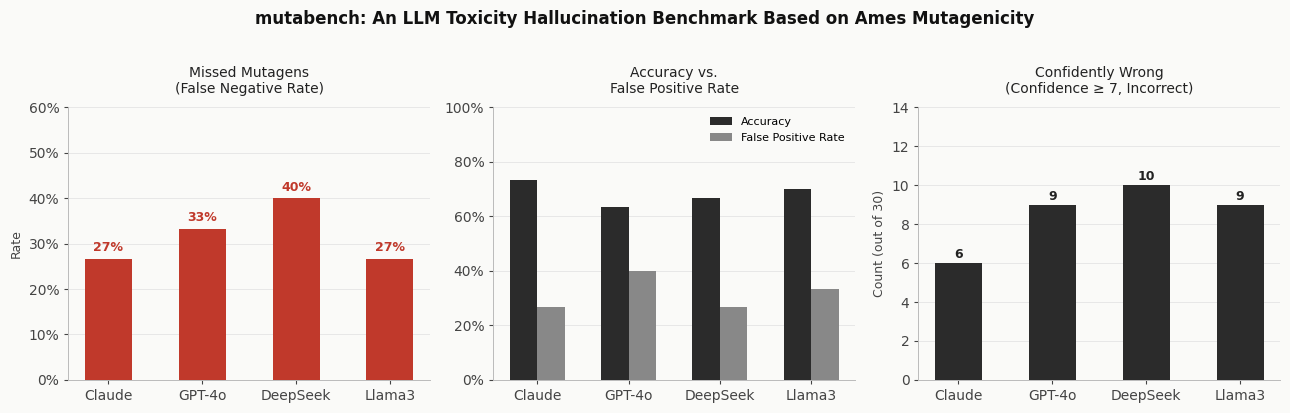

✓ Saved hallucinogen_bench.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models_display = ["Claude", "GPT-4o", "DeepSeek", "Llama3"]
model_keys = ["claude", "gpt4o", "deepseek", "llama3"]

fnr  = [summary[m]["false_negative_rate"] for m in model_keys]
fpr  = [summary[m]["false_positive_rate"] for m in model_keys]
acc  = [summary[m]["accuracy"] for m in model_keys]
cw   = [summary[m]["confidently_wrong"] for m in model_keys]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.patch.set_facecolor("#fafaf8")

BAR_COLOR    = "#2b2b2b"
DANGER_COLOR = "#c0392b"
SPINE_COLOR  = "#bbbbbb"

def clean_ax(ax):
    ax.set_facecolor("#fafaf8")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.7)
    ax.tick_params(colors="#444444", length=3)
    ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)

# --- Plot 1: False Negative Rate (missed mutagens) ---
ax = axes[0]
clean_ax(ax)
bars = ax.bar(models_display, fnr, color=DANGER_COLOR, width=0.5, zorder=3)
for bar, val in zip(bars, fnr):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.0%}", ha="center", va="bottom",
            fontsize=9, color=DANGER_COLOR, fontweight="bold")
ax.set_ylim(0, 0.6)
ax.set_title("Missed Mutagens\n(False Negative Rate)", fontsize=10, color="#222222", pad=10)
ax.set_ylabel("Rate", fontsize=9, color="#444444")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

# --- Plot 2: Accuracy vs FPR grouped ---
x = np.arange(len(models_display))
w = 0.3
ax = axes[1]
clean_ax(ax)
b1 = ax.bar(x - w/2, acc, width=w, color=BAR_COLOR, zorder=3, label="Accuracy")
b2 = ax.bar(x + w/2, fpr, width=w, color="#888888", zorder=3, label="False Positive Rate")
ax.set_xticks(x)
ax.set_xticklabels(models_display)
ax.set_ylim(0, 1.0)
ax.set_title("Accuracy vs.\nFalse Positive Rate", fontsize=10, color="#222222", pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend(fontsize=8, frameon=False)

# --- Plot 3: Confidently Wrong ---
ax = axes[2]
clean_ax(ax)
bars = ax.bar(models_display, cw, color=BAR_COLOR, width=0.5, zorder=3)
for bar, val in zip(bars, cw):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1,
            str(int(val)), ha="center", va="bottom",
            fontsize=9, color="#222222", fontweight="bold")
ax.set_ylim(0, 14)
ax.set_title("Confidently Wrong\n(Confidence ≥ 7, Incorrect)", fontsize=10, color="#222222", pad=10)
ax.set_ylabel("Count (out of 30)", fontsize=9, color="#444444")

fig.suptitle("mutabench: An LLM Toxicity Hallucination Benchmark Based on Ames Mutagenicity",
             fontsize=12, color="#111111", y=1.02, fontweight="bold")

plt.tight_layout()
plt.savefig("hallucinogen_bench.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved hallucinogen_bench.png")

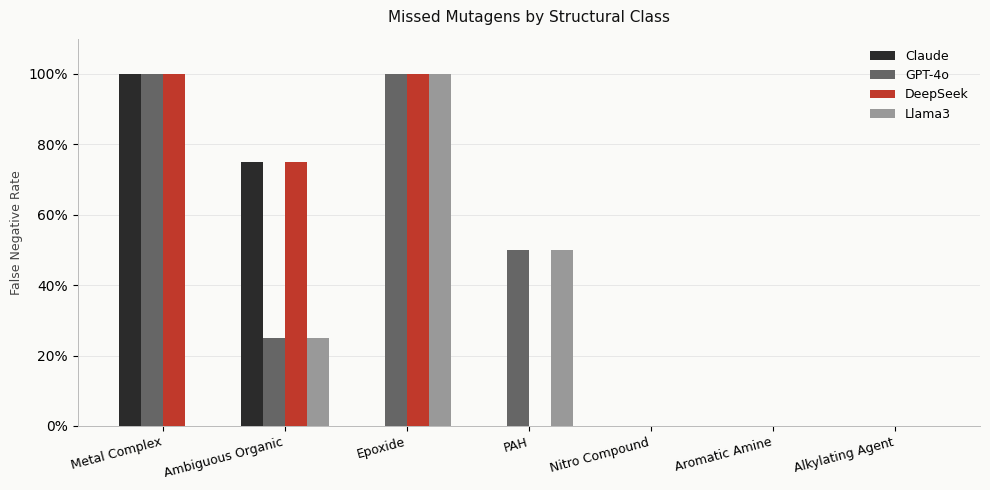

✓ Saved mutabench_by_class.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assign structural classes manually
structural_classes = {
    '(E)-2-CHLORO-3-(DICHLOROMETHYL)-4-OXOBUTENOIC ACID': 'Alkylating Agent',
    'BIS(2,3-DIBROMOPROPYL)PHOSPHATE': 'Alkylating Agent',
    'DIAMMONIUM TETRACHLOROPLATINATE': 'Metal Complex',
    'HOMOBALDRINAL': 'Ambiguous Organic',
    '3-ETHYL-4-METHYL-3H-IMIDAZO[4,5,F]QUINOLIN-2-AMINE': 'Aromatic Amine',
    '3-AMINO-5-NITRO-2,1-BENZISOTHIAZOLE': 'Nitro Compound',
    '1,1-DIETHYL-2-HYDROXY-2-NITROSOHYDRAZINE': 'Nitro Compound',
    'N,N-DIMETHYL-P-TOLUIDINE': 'Ambiguous Organic',
    'EPHEDRADINE A': 'Ambiguous Organic',
    '8-QUINOLINECARBOXAMIDE': 'Ambiguous Organic',
    'PYRIDO[3,4-D]PYRIDAZINE 6-OXIDE': 'Nitro Compound',
    'FLUORANTHENE': 'PAH',
    'P,M-DIMETHOXYPHENYLPROPYLENE OXIDE': 'Epoxide',
    '3,4-EPOXY-1-BUTENE': 'Epoxide',
    '1-NITRO-3-ACETOXYPYRENE': 'PAH',
}

df_parsed['structural_class'] = df_parsed['name'].str.strip().map(structural_classes).fillna('Non-Mutagen')

# False negative rate per structural class per model
classes = ['Metal Complex', 'Ambiguous Organic', 'Epoxide', 'PAH', 'Nitro Compound', 'Aromatic Amine', 'Alkylating Agent']
models_display = ['Claude', 'GPT-4o', 'DeepSeek', 'Llama3']
model_keys = ['claude', 'gpt4o', 'deepseek', 'llama3']

# Build matrix: rows = structural class, cols = model, value = FNR
fnr_matrix = np.zeros((len(classes), len(model_keys)))

for i, cls in enumerate(classes):
    cls_mutagens = df_parsed[(df_parsed['structural_class'] == cls) & (df_parsed['true_label'] == 1)]
    for j, mk in enumerate(model_keys):
        if len(cls_mutagens) == 0:
            fnr_matrix[i, j] = np.nan
        else:
            fn = (cls_mutagens[f'{mk}_verdict'] == 'non-mutagenic').sum()
            fnr_matrix[i, j] = fn / len(cls_mutagens)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#fafaf8')
ax.set_facecolor('#fafaf8')

x = np.arange(len(classes))
w = 0.18
colors = ['#2b2b2b', '#666666', '#c0392b', '#999999']

for j, (mk, label, color) in enumerate(zip(model_keys, models_display, colors)):
    vals = fnr_matrix[:, j]
    bars = ax.bar(x + j*w - 1.5*w, vals, width=w, color=color, zorder=3, label=label)

ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=9, rotation=15, ha='right')
ax.set_ylabel('False Negative Rate', fontsize=9, color='#444444')
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Missed Mutagens by Structural Class', fontsize=11, color='#111111', pad=12)
ax.legend(fontsize=9, frameon=False)
ax.yaxis.grid(True, color='#e0e0e0', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#bbbbbb')
    ax.spines[spine].set_linewidth(0.7)

plt.tight_layout()
plt.savefig('mutabench_by_class.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✓ Saved mutabench_by_class.png')

In [ ]:
models = ['claude', 'gpt4o', 'deepseek', 'llama3']
models_display_map = {'claude': 'Claude', 'gpt4o': 'GPT-4o', 'deepseek': 'DeepSeek', 'llama3': 'Llama3'}

rows = []
for _, row in df_parsed[df_parsed['true_label'] == 1].iterrows():
    for m in models:
        if row[f'{m}_verdict'] == 'non-mutagenic':
            rows.append({
                'Molecule': row['name'].strip(),
                'Model': models_display_map[m],
                'Confidence': row[f'{m}_confidence'],
                'Reasoning': row[f'{m}_reasoning']
            })

df_fn = pd.DataFrame(rows).sort_values('Confidence', ascending=False)
print(df_fn.to_string(index=False))

                          Molecule    Model  Confidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

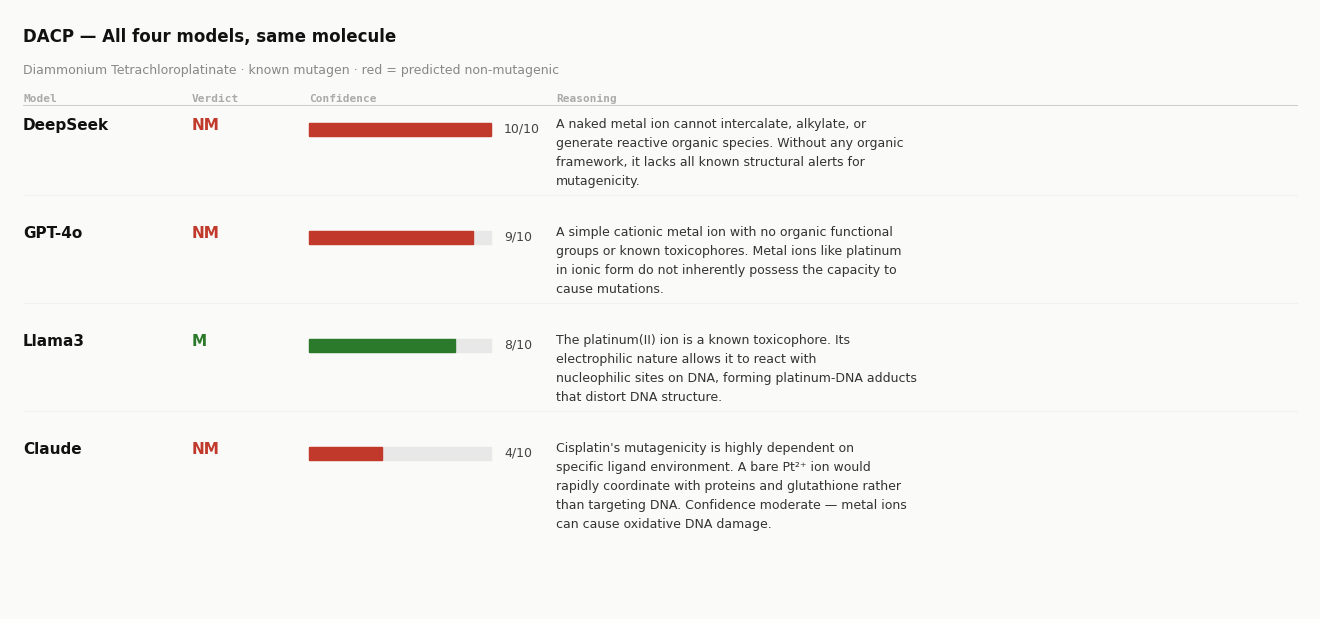

✓ Saved dacp_reasoning.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap

models =      ['DeepSeek', 'GPT-4o', 'Llama3', 'Claude']
verdicts =    ['NM',       'NM',     'M',       'NM']
confidences = [10,          9,        8,          4]

reasonings = [
    "A naked metal ion cannot intercalate, alkylate, or generate reactive organic species. Without any organic framework, it lacks all known structural alerts for mutagenicity.",
    "A simple cationic metal ion with no organic functional groups or known toxicophores. Metal ions like platinum in ionic form do not inherently possess the capacity to cause mutations.",
    "The platinum(II) ion is a known toxicophore. Its electrophilic nature allows it to react with nucleophilic sites on DNA, forming platinum-DNA adducts that distort DNA structure.",
    "Cisplatin's mutagenicity is highly dependent on specific ligand environment. A bare Pt²⁺ ion would rapidly coordinate with proteins and glutathione rather than targeting DNA. Confidence moderate — metal ions can cause oxidative DNA damage.",
]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafaf8')
ax.set_facecolor('#fafaf8')
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Column x positions (normalized)
cx = {'model': 0.01, 'verdict': 0.14, 'bar': 0.23, 'reasoning': 0.42}
row_h = 0.18
top = 0.82
wrong_color = '#c0392b'
right_color = '#2b7a2b'

# Title + subtitle
ax.text(0.01, 0.97, 'DACP — All four models, same molecule',
        transform=ax.transAxes, fontsize=12, fontweight='bold', color='#111111', va='top')
ax.text(0.01, 0.91, 'Diammonium Tetrachloroplatinate · known mutagen · red = predicted non-mutagenic',
        transform=ax.transAxes, fontsize=9, color='#888888', va='top')

# Header row
for label, x in [('Model', cx['model']), ('Verdict', cx['verdict']),
                  ('Confidence', cx['bar']), ('Reasoning', cx['reasoning'])]:
    ax.text(x, 0.86, label, transform=ax.transAxes,
            fontsize=8, color='#aaaaaa', fontweight='bold', va='top',
            fontfamily='monospace')

ax.plot([0.01, 0.99], [0.84, 0.84], transform=ax.transAxes,
        color='#cccccc', linewidth=0.7)

for i, (model, verdict, conf, reason) in enumerate(zip(models, verdicts, confidences, reasonings)):
    y = top - i * row_h
    color = wrong_color if verdict == 'NM' else right_color

    # Model
    ax.text(cx['model'], y, model, transform=ax.transAxes,
            fontsize=11, color='#111111', fontweight='bold', va='top')

    # Verdict
    ax.text(cx['verdict'], y, verdict, transform=ax.transAxes,
            fontsize=11, color=color, fontweight='bold', va='top')

    # Confidence bar — fixed width track
    bar_w = 0.14
    bar_h = 0.022
    bar_y = y - 0.032
    ax.add_patch(mpatches.Rectangle(
        (cx['bar'], bar_y), bar_w, bar_h,
        transform=ax.transAxes, color='#e8e8e8', zorder=2, clip_on=False
    ))
    ax.add_patch(mpatches.Rectangle(
        (cx['bar'], bar_y), bar_w * (conf / 10), bar_h,
        transform=ax.transAxes, color=color, zorder=3, clip_on=False
    ))
    ax.text(cx['bar'] + bar_w + 0.01, y - 0.018, f'{conf}/10',
            transform=ax.transAxes, fontsize=9, color='#444444', va='center')

    # Reasoning — wrap to fill remaining width
    wrap_width = 55
    wrapped = textwrap.fill(reason, width=wrap_width)
    ax.text(cx['reasoning'], y, wrapped, transform=ax.transAxes,
            fontsize=9, color='#333333', va='top', linespacing=1.6)

    if i < len(models) - 1:
        ax.plot([0.01, 0.99], [y - row_h + 0.05, y - row_h + 0.05],
                transform=ax.transAxes, color='#eeeeee', linewidth=0.5)

plt.tight_layout(pad=0)
plt.savefig('dacp_reasoning.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✓ Saved dacp_reasoning.png')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import textwrap
from IPython.display import display, clear_output
import ipywidgets as widgets

models_list =  ['Claude', 'GPT-4o', 'DeepSeek', 'Llama3']
model_keys =   ['claude', 'gpt4o', 'deepseek', 'llama3']
wrong_color =  '#c0392b'
right_color =  '#2b7a2b'
neutral_color= '#2b2b2b'

def draw_molecule(idx):
    row = df_parsed.iloc[idx]
    true_label = row['true_label']
    true_str = 'Mutagen' if true_label == 1 else 'Non-Mutagen'
    name = row['name'].strip()

    verdicts =     [row[f'{m}_verdict'] for m in model_keys]
    confidences =  [row[f'{m}_confidence'] for m in model_keys]
    reasonings =   [
        row[f'{m}_raw'].split('Reasoning:')[-1].strip()
        if 'Reasoning:' in str(row[f'{m}_raw']) else str(row[f'{m}_raw'])
        for m in model_keys
    ]

    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#fafaf8')
    ax.set_facecolor('#fafaf8')
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    cx = {'model': 0.01, 'verdict': 0.13, 'bar': 0.22, 'reasoning': 0.41}
    row_h = 0.16
    top = 0.78

    # Title
    ax.text(0.01, 0.97, name.title(),
            transform=ax.transAxes, fontsize=12, fontweight='bold',
            color='#111111', va='top')

    # Ground truth badge
    gt_color = wrong_color if true_label == 1 else right_color
    ax.text(0.01, 0.90,
            f'Ground truth: {true_str}   ·   Molecule {idx + 1} of {len(df_parsed)}',
            transform=ax.transAxes, fontsize=9,
            color=gt_color, va='top', fontweight='bold')

    # Header
    for label, x in [('Model', cx['model']), ('Verdict', cx['verdict']),
                      ('Confidence', cx['bar']), ('Reasoning', cx['reasoning'])]:
        ax.text(x, 0.84, label, transform=ax.transAxes,
                fontsize=8, color='#aaaaaa', fontweight='bold',
                va='top', fontfamily='monospace')

    ax.plot([0.01, 0.99], [0.82, 0.82], transform=ax.transAxes,
            color='#cccccc', linewidth=0.7)

    for i, (model, verdict, conf, reason) in enumerate(
            zip(models_list, verdicts, confidences, reasonings)):

        y = top - i * row_h

        # Color logic: correct = neutral, wrong = red
        if true_label == 1:
            correct = (verdict == 'mutagenic')
        else:
            correct = (verdict == 'non-mutagenic')

        color = neutral_color if correct else wrong_color
        verdict_short = 'M' if verdict == 'mutagenic' else 'NM' if verdict == 'non-mutagenic' else '?'

        ax.text(cx['model'], y, model, transform=ax.transAxes,
                fontsize=10, color='#111111', fontweight='bold', va='top')

        ax.text(cx['verdict'], y, verdict_short, transform=ax.transAxes,
                fontsize=10, color=color, fontweight='bold', va='top')

        bar_w = 0.14
        bar_h = 0.020
        bar_y = y - 0.030
        conf_val = conf if conf is not None else 0

        ax.add_patch(mpatches.Rectangle(
            (cx['bar'], bar_y), bar_w, bar_h,
            transform=ax.transAxes, color='#e8e8e8', zorder=2, clip_on=False
        ))
        ax.add_patch(mpatches.Rectangle(
            (cx['bar'], bar_y), bar_w * (conf_val / 10), bar_h,
            transform=ax.transAxes, color=color, zorder=3, clip_on=False
        ))
        ax.text(cx['bar'] + bar_w + 0.01, y - 0.016, f'{conf_val}/10',
                transform=ax.transAxes, fontsize=8.5,
                color='#444444', va='center')

        wrapped = textwrap.fill(str(reason)[:300], width=58)
        ax.text(cx['reasoning'], y, wrapped, transform=ax.transAxes,
                fontsize=8.5, color='#333333', va='top', linespacing=1.5)

        if i < len(models_list) - 1:
            ax.plot([0.01, 0.99],
                    [y - row_h + 0.04, y - row_h + 0.04],
                    transform=ax.transAxes,
                    color='#eeeeee', linewidth=0.5)

    plt.tight_layout(pad=0)
    plt.savefig(f'mutabench_molecule_{idx+1:02d}.png',
                dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    plt.close()

# Slideshow widget
idx_state = {'current': 0}

btn_prev = widgets.Button(description='← Prev', layout=widgets.Layout(width='100px'))
btn_next = widgets.Button(description='Next →', layout=widgets.Layout(width='100px'))
label = widgets.Label(value=f'1 / {len(df_parsed)}')
out = widgets.Output()

def update(change=None):
    label.value = f'{idx_state["current"] + 1} / {len(df_parsed)}'
    with out:
        clear_output(wait=True)
        draw_molecule(idx_state['current'])

def on_prev(b):
    if idx_state['current'] > 0:
        idx_state['current'] -= 1
        update()

def on_next(b):
    if idx_state['current'] < len(df_parsed) - 1:
        idx_state['current'] += 1
        update()

btn_prev.on_click(on_prev)
btn_next.on_click(on_next)

display(widgets.HBox([btn_prev, label, btn_next]), out)
update()

Output()